#### **I. Import các thư viện**

In [1]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

#### **II. Import Data**

In [2]:

df = pd.read_csv('air_quality_data_1.csv')  
df  

,Local Time,City,Country code,timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,UTC Time
0,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,2022-12-31T17:00:00
1,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,2022-12-31T18:00:00
2,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,2022-12-31T19:00:00
3,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,2022-12-31T20:00:00
4,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,2022-12-31T21:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
17544,12/31/2024 20:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,1613.0,8.0,2.2,174.0,155.0,32.0,2024-12-31T13:00:00
17545,12/31/2024 21:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,1613.0,8.0,2.2,174.0,155.0,32.0,2024-12-31T14:00:00
17546,12/31/2024 22:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,1613.0,8.0,2.2,174.0,155.0,32.0,2024-12-31T15:00:00
17547,12/31/2024 23:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,264,1214.0,17.7,8.1,153.7,141.0,56.7,2024-12-31T16:00:00


In [3]:
df_1 = df.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17549 entries, 0 to 17548
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Local Time    17549 non-null  object 
 1   City          17549 non-null  object 
 2   Country code  17549 non-null  object 
 3   timezone      17549 non-null  object 
 4   AQI           17549 non-null  int64  
 5   CO            17549 non-null  float64
 6   NO2           17549 non-null  float64
 7   O3            17549 non-null  float64
 8   PM10          17549 non-null  float64
 9   PM25          17549 non-null  float64
 10  SO2           17549 non-null  float64
 11  UTC Time      17549 non-null  object 
dtypes: float64(6), int64(1), object(5)
memory usage: 1.6+ MB


In [5]:
df.shape

(17549, 12)

In [6]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2
count,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000
mean,119.204855,586.272067,26.041666,53.985384,69.882352,49.363080,66.185048
std,54.220457,969.610472,28.066354,44.884866,84.190815,42.344122,49.170026
min,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000
25%,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000
50%,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000
75%,154.000000,571.500000,29.000000,74.000000,80.000000,59.000000,97.000000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000


#### **II. Phân tích và khám phá dữ liệu**
Trong phần này, phân tích khám phá dữ liệu (EDA) sẽ được sử dụng để xem xét bộ dữ liệu nhằm tìm kiếm các khuôn mẫu, phát hiện bất thường, kiểm định giả thuyết và xác minh các giả định. Quá trình này được thực hiện thông qua các thống kê mô tả và biểu đồ trực quan.

Trong suốt hơn 45 năm qua, Chỉ số Chất lượng Không khí (Air Quality Index – AQI), được phát triển bởi Cơ quan Bảo vệ Môi trường Hoa Kỳ (USEPA), đã cung cấp những thông tin quan trọng cho công chúng về tình trạng ô nhiễm không khí.
Chỉ số AQI được tính toán dựa trên nồng độ đo được của các chất ô nhiễm bao gồm: Carbon Monoxide (CO), Nitrogen Dioxide (NO2), Ozone (O3), hạt bụi mịn PM2.5 và PM10, cùng với Sulfur Dioxide (SO2).

Trong đó, PM25 (biểu thị vật có đường kính nhỏ hơn hoặc bằng 2.5 micromet) là yếu tố chính gây nguy hại đến sức khỏe con người, và thường được sử dụng như chỉ tiêu quan trọng trong các tiêu chuẩn đánh giá chất lượng không khí.

Theo Báo cáo Chất lượng Không khí Toàn cầu năm 2019 của [IQAir](https://www.iqair.com/vi/newsroom/resources-what-is-aqi), nồng độ PM₂.₅ được chia thành các nhóm mức độ khác nhau để xác định tình trạng chất lượng không khí, cụ thể như sau:![Screenshot 2025-10-17 215622.png](<attachment:Screenshot 2025-10-17 215622.png>)

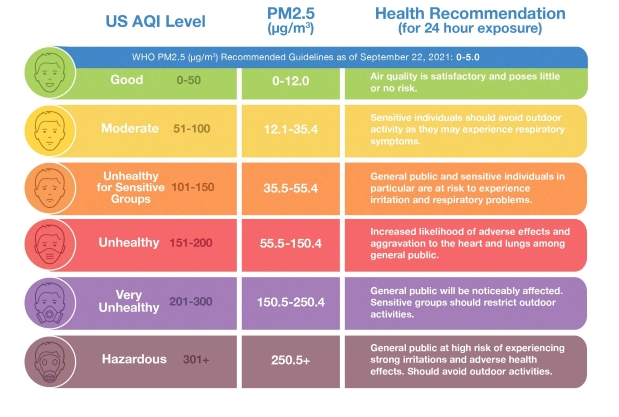
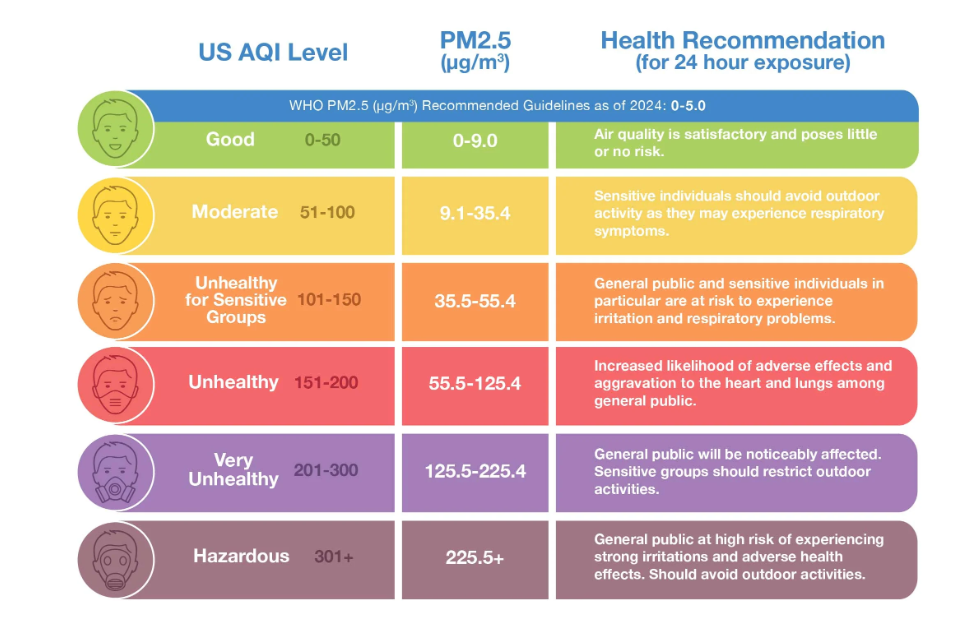

In [7]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2
count,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000
mean,119.204855,586.272067,26.041666,53.985384,69.882352,49.363080,66.185048
std,54.220457,969.610472,28.066354,44.884866,84.190815,42.344122,49.170026
min,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000
25%,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000
50%,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000
75%,154.000000,571.500000,29.000000,74.000000,80.000000,59.000000,97.000000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000


In [8]:
df.head(10)

,Local Time,City,Country code,timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,UTC Time
0,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,2022-12-31T17:00:00
1,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,2022-12-31T18:00:00
2,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,2022-12-31T19:00:00
3,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,2022-12-31T20:00:00
4,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,2022-12-31T21:00:00
5,1/1/2023 5:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,172,204.8,8.3,46.0,90.0,72.0,56.7,2022-12-31T22:00:00
6,1/1/2023 6:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,210.7,10.7,42.0,80.0,64.0,57.3,2022-12-31T23:00:00
7,1/1/2023 7:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,160,216.5,13.0,38.0,78.8,63.0,58.0,2023-01-01T00:00:00
8,1/1/2023 8:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,209.5,11.0,45.7,83.8,67.0,57.7,2023-01-01T01:00:00
9,1/1/2023 9:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,176,202.5,9.0,53.3,93.8,75.0,57.3,2023-01-01T02:00:00


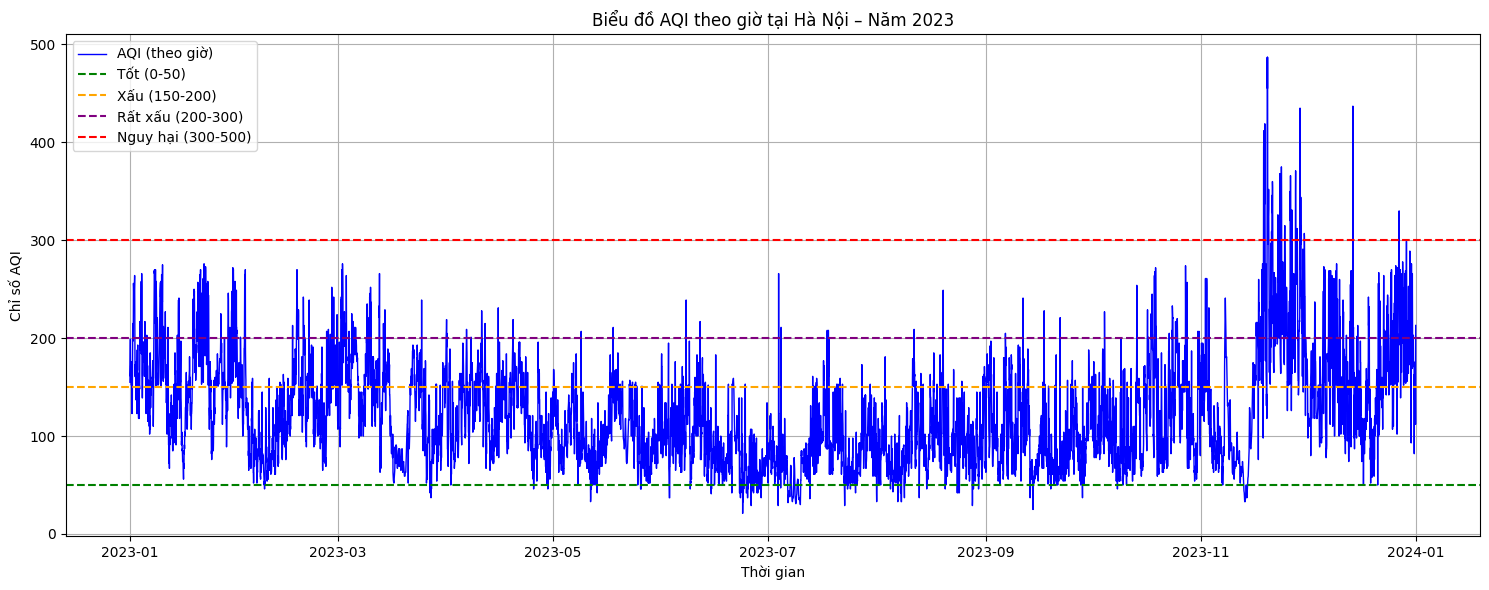

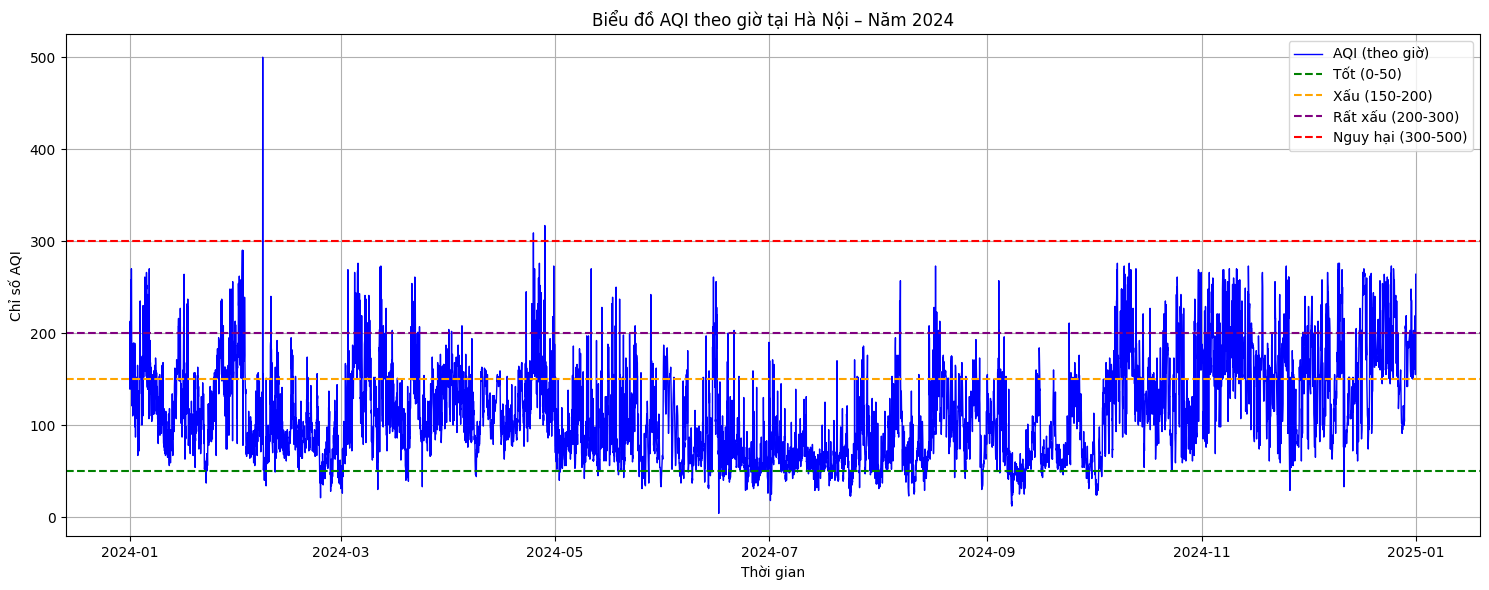

Năm 2023: AQI cao nhất = 487 vào lúc 2023-11-19 20:00:00
Năm 2024: AQI cao nhất = 500 vào lúc 2024-02-07 19:00:00


In [9]:
df['Local Time'] = pd.to_datetime(df['Local Time'])

df_2023 = df[df['Local Time'].dt.year == 2023]
df_2024 = df[df['Local Time'].dt.year == 2024]

# Biểu đồ năm 2023
plt.figure(figsize=(15,6))
plt.plot(df_2023['Local Time'], df_2023['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2023')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Biểu đồ năm 2024
plt.figure(figsize=(15,6))
plt.plot(df_2024['Local Time'], df_2024['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2024')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


max_2023 = df_2023.loc[df_2023['AQI'].idxmax()]
max_2024 = df_2024.loc[df_2024['AQI'].idxmax()]
print(f"Năm 2023: AQI cao nhất = {max_2023['AQI']} vào lúc {max_2023['Local Time']}")
print(f"Năm 2024: AQI cao nhất = {max_2024['AQI']} vào lúc {max_2024['Local Time']}")


Từ biểu đồ, có thể thấy chỉ số AQI của Hà Nội dao động chủ yếu trong khoảng 50-200 (Trung bình đến Xấu). Chỉ số này hiếm khi duy trì ở mức Tốt (0-50). Chỉ số cũng có tần suất cao vượt ngưỡng Không tốt. Đặc biệt, chỉ số này ở mức Nguy hại (>300) vào các thời điểm khác nhau từ tháng 11 đến giữa tháng 2, đạt mức cao nhất trong năm vào lúc 19h 7/2/2024 và đạt AQI = 487 vào lúc 20h ngày 19/11/2023.

Nhìn chung, Hà Nội đã phải đối mặt với tình trạng ô nhiễm không khí nghiêm trọng trong năm qua, điều này có thể ảnh hưởng nghiêm trọng đến sức khỏe của người dân thành phố.

In [10]:

df['month'] = df['Local Time'].dt.month
df['year'] = df['Local Time'].dt.year

monthly_stats = (df.groupby(['year', 'month']).agg(
    mean_AQI = ('AQI', 'mean'),
    max_AQI = ('AQI', 'max'),
    std_AQI = ('AQI', 'std'),
    count_hazardous=('AQI', lambda x: (x>300).sum())
    
).reset_index()
                )
monthly_stats = monthly_stats.sort_values('mean_AQI', ascending=False)
months_over_300 = monthly_stats[monthly_stats['count_hazardous'] > 0]
print(months_over_300[['year', 'month', 'mean_AQI', 'count_hazardous']])


    year  month    mean_AQI  count_hazardous
10  2023     11  166.684722               52
11  2023     12  165.413978                2
15  2024      4  128.120666                2
13  2024      2   96.771552                1


In [14]:
df_1['Local Time'] = pd.to_datetime(df_1['Local Time'])


In [15]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17549 entries, 0 to 17548
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Local Time    17549 non-null  datetime64[ns]
 1   City          17549 non-null  object        
 2   Country code  17549 non-null  object        
 3   timezone      17549 non-null  object        
 4   AQI           17549 non-null  int64         
 5   CO            17549 non-null  float64       
 6   NO2           17549 non-null  float64       
 7   O3            17549 non-null  float64       
 8   PM10          17549 non-null  float64       
 9   PM25          17549 non-null  float64       
 10  SO2           17549 non-null  float64       
 11  UTC Time      17549 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 1.6+ MB


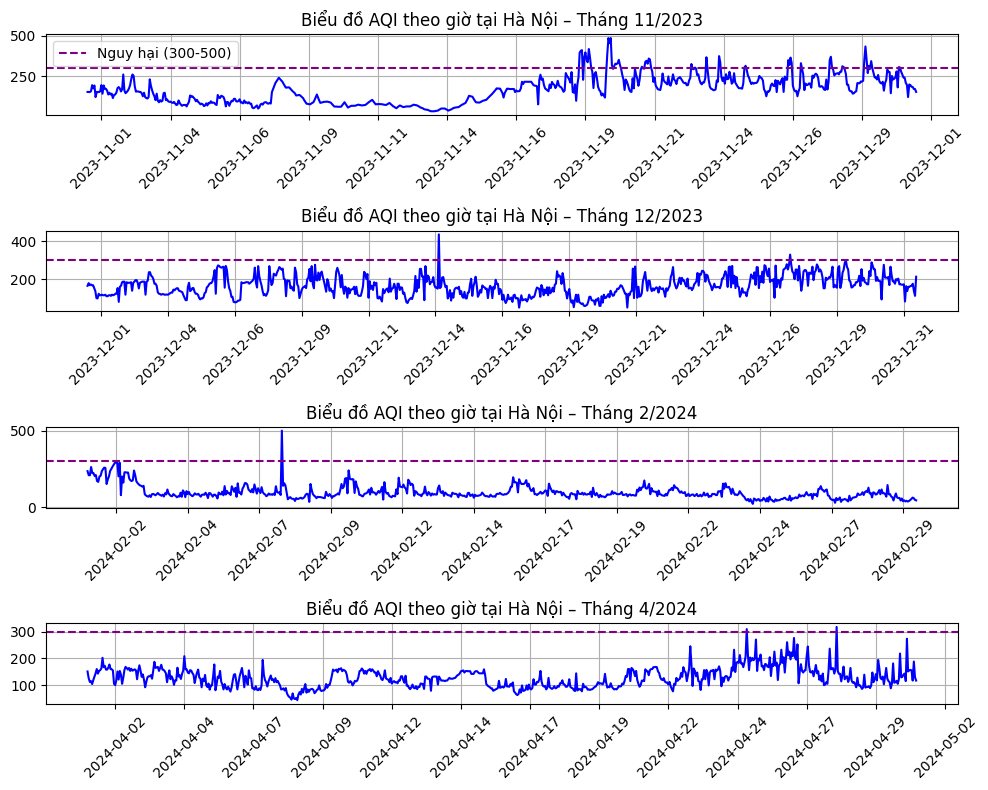

In [19]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8))

# Set index cho df_1
df_1 = df_1.set_index('Local Time')

# Vẽ biểu đồ cho từng tháng
axs[0].plot(df_1.loc['2023-11-01':'2023-11-30']["AQI"], color='b')
axs[0].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 11/2023')
axs[0].grid(True)
axs[0].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')
axs[0].legend()


axs[1].plot(df_1.loc['2023-12-01':'2023-12-31']["AQI"], color='b')
axs[1].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 12/2023')
axs[1].grid(True)
axs[1].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[2].plot(df_1.loc['2024-02-01':'2024-02-29']["AQI"], color='b')
axs[2].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 2/2024')
axs[2].grid(True)
axs[2].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[3].plot(df_1.loc['2024-04-01':'2024-04-30']["AQI"], color='b')
axs[3].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 4/2024')
axs[3].grid(True)
axs[3].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


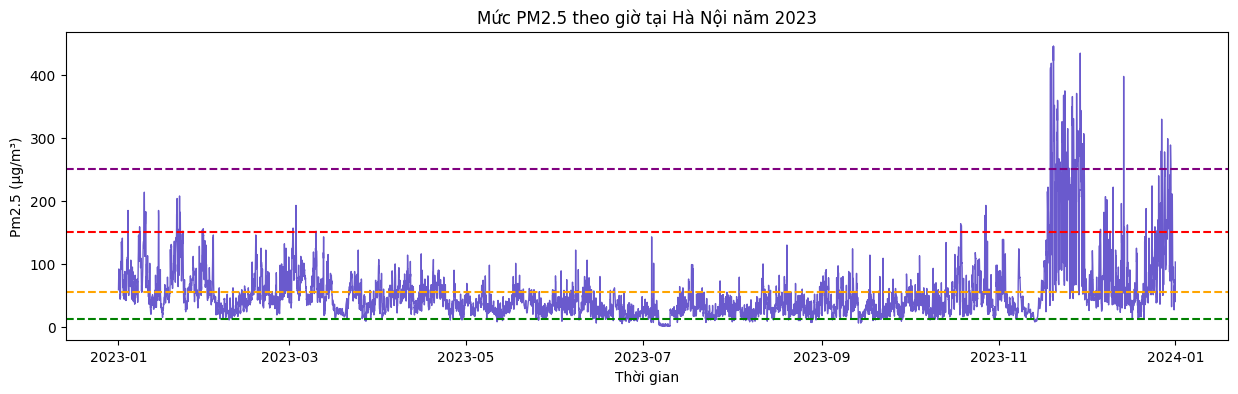

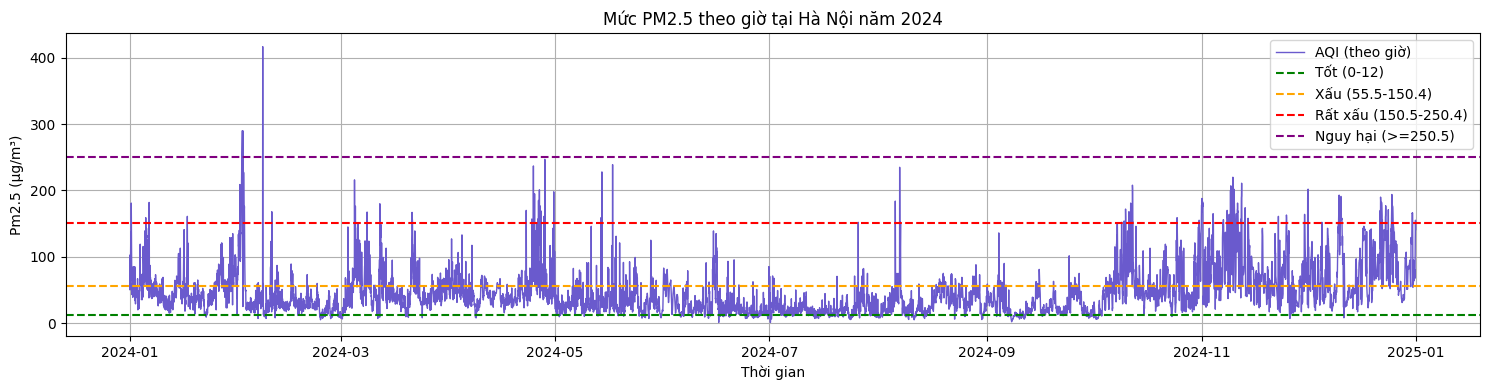

In [ ]:
# Năm 2023

plt.figure(figsize=(15, 4))
plt.plot(df_2023['Local Time'], df_2023['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2023')
plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')

# Năm 2024
plt.figure(figsize=(15, 4))
plt.plot(df_2024['Local Time'], df_2024['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2024')

plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')


plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:

hourly_pm25 = df['PM25'].groupby(df.index.hour).mean()
highest_hours = hourly_pm25.nlargest(5) 
print(highest_hours)

Local Time
8     56.333871
20    56.053666
9     55.453078
21    54.669398
6     54.371696
Name: PM25, dtype: float64


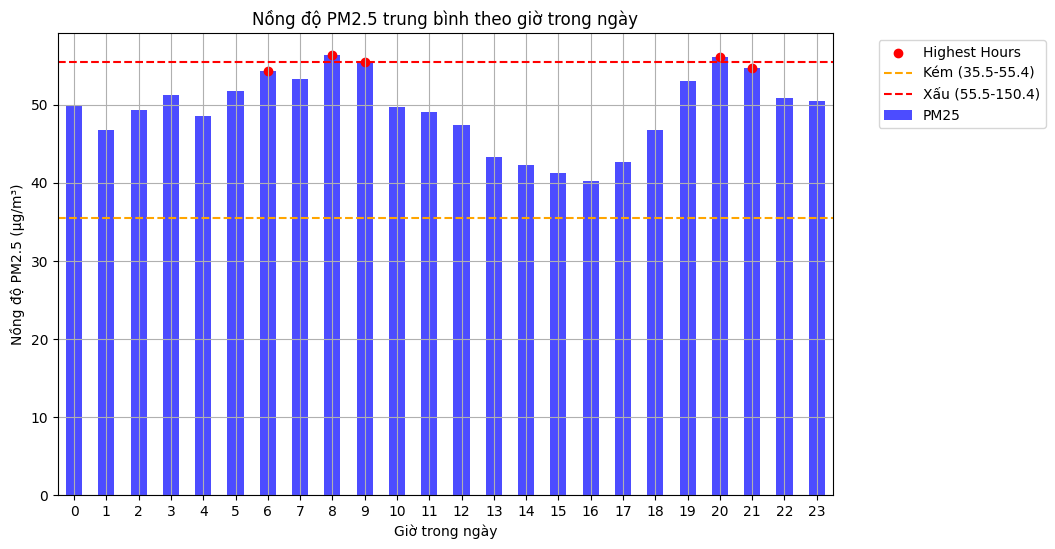

In [28]:
plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7)  
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Highest Hours') 
plt.title('Nồng độ PM2.5 trung bình theo giờ trong ngày')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.xticks(rotation='horizontal')

plt.show()


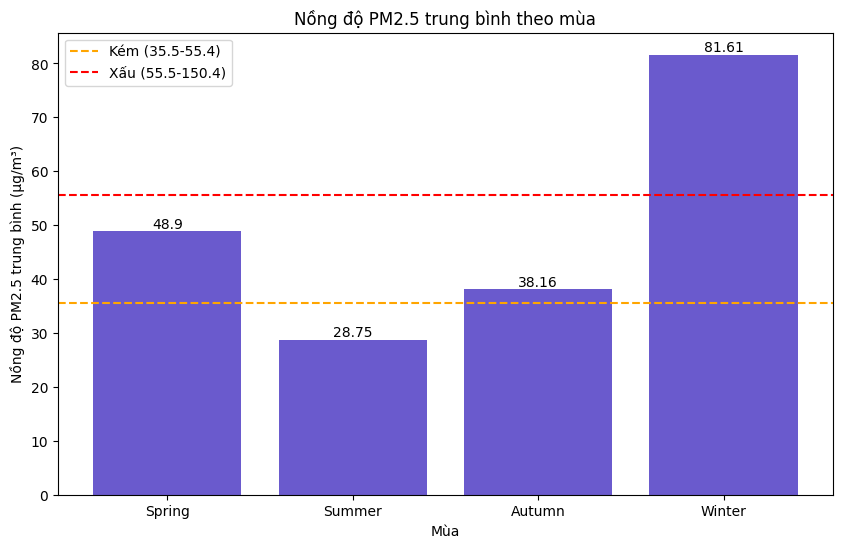

In [29]:
seasons = {
    'Spring': [2, 3, 4],
    'Summer': [5, 6, 7],
    'Autumn': [8, 9, 10],
    'Winter': [11, 12, 1]
}


seasonal_pm25 = {}
for season, months in seasons.items():
    seasonal_pm25[season] = df.loc[df.index.month.isin(months), 'PM25'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_pm25.keys(), seasonal_pm25.values(), color='slateblue')
plt.title('Nồng độ PM2.5 trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Nồng độ PM2.5 trung bình (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')
plt.legend()


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

In [ ]:
# tétte